## Diabetes Predictions using Decision Tree Regressor

In [ ]:
from sklearn.datasets import load_diabetes
dataset = load_diabetes()
dataset

In [ ]:
print(dataset.DESCR)

In [7]:
import pandas as pd
import numpy as np

df_diabetes = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
df_diabetes.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [9]:
## Independent and Dependent features
X = df_diabetes
y = dataset.target  

In [10]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

In [11]:
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
249,-0.012780,-0.044642,0.060618,0.052858,0.047965,0.029375,-0.017629,0.034309,0.070207,0.007207
389,-0.005515,0.050680,0.001339,-0.084856,-0.011201,-0.016658,0.048640,-0.039493,-0.041176,-0.088062
121,0.063504,-0.044642,0.017506,0.021872,0.008063,0.021546,-0.036038,0.034309,0.019907,0.011349
195,0.027178,0.050680,0.025051,0.014987,0.025950,0.048477,-0.039719,0.034309,0.007838,0.023775
69,0.016281,-0.044642,-0.046085,-0.005670,-0.075870,-0.061438,-0.013948,-0.039493,-0.051404,0.019633


In [12]:
X_train.corr()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
age,1.000000,0.197408,0.198359,0.394903,0.238375,0.192920,-0.128403,0.227110,0.314151,0.351570
sex,0.197408,1.000000,0.108261,0.221914,0.057674,0.180315,-0.379464,0.324882,0.150956,0.193322
bmi,0.198359,0.108261,1.000000,0.356324,0.226047,0.248146,-0.395021,0.412826,0.435505,0.358273
bp,0.394903,0.221914,0.356324,1.000000,0.238295,0.165632,-0.192505,0.249141,0.420236,0.368882
s1,0.238375,0.057674,0.226047,0.238295,1.000000,0.872781,0.006313,0.559626,0.566312,0.356280
s2,0.192920,0.180315,0.248146,0.165632,0.872781,1.000000,-0.265114,0.684840,0.325759,0.315890
s3,-0.128403,-0.379464,-0.395021,-0.192505,0.006313,-0.265114,1.000000,-0.754616,-0.370523,-0.297055
s4,0.227110,0.324882,0.412826,0.249141,0.559626,0.684840,-0.754616,1.000000,0.609983,0.436311
s5,0.314151,0.150956,0.435505,0.420236,0.566312,0.325759,-0.370523,0.609983,1.000000,0.490970
s6,0.351570,0.193322,0.358273,0.368882,0.356280,0.315890,-0.297055,0.436311,0.490970,1.000000


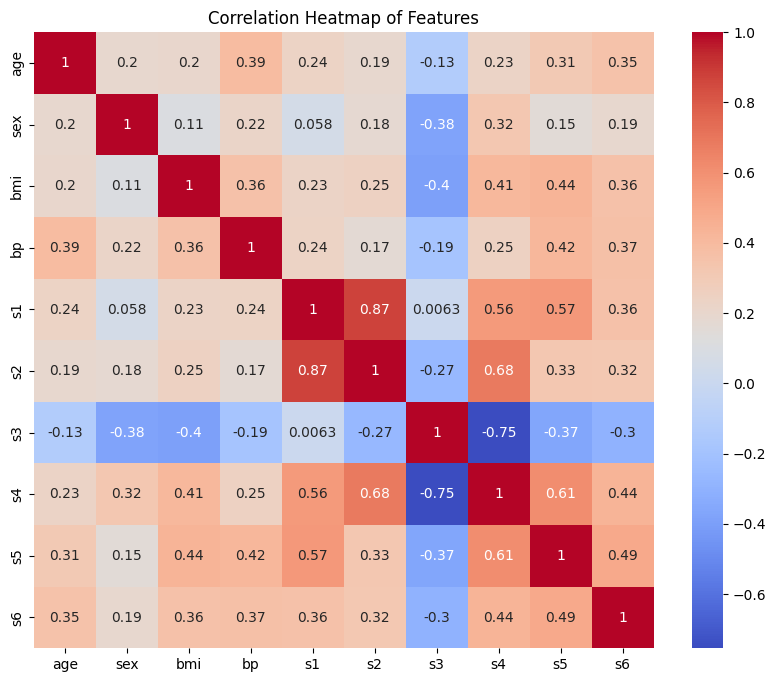

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))    # Set the figure size for better visibility
sns.heatmap(X_train.corr(), annot=True, cmap='coolwarm')   # Create a heatmap of the correlation matrix with annotations and a color map
plt.title('Correlation Heatmap of Features')
plt.show()

In [ ]:
## Model Building
'''
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_pred
'''       
 ## As usual, the model is overfitting. We will try to reduce the overfitting by tuning the hyperparameters of the model.

In [14]:
## Hyperparameter Tuning
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()

param_grid = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'splitter': ['best', 'random'],
    'max_depth': [None, 1, 2, 3, 4, 5, 10, 20, 25],
    'max_features': [None, 'auto', 'sqrt', 'log2']
}

In [15]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(),
             param_grid={'criterion': ['squared_error', 'friedman_mse',
                                       'absolute_error'],
                         'max_depth': [None, 1, 2, 3, 4, 5, 10, 20, 25],
                         'max_features': [None, 'auto', 'sqrt', 'log2'],
                         'splitter': ['best', 'random']},
             scoring='neg_mean_squared_error')

In [16]:
grid_search.best_params_

{'criterion': 'squared_error',
 'max_depth': 4,
 'max_features': None,
 'splitter': 'random'}

In [17]:
## Prediction using the best parameters
y_pred = grid_search.predict(X_test)


## Evaluation of the model
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(mse, r2, mae)

4231.7778625581295 0.3312266394690786 53.1471340294055


In [19]:
selectedmodel = DecisionTreeRegressor(criterion='squared_error', max_depth=4, max_features=None, splitter='random')
selectedmodel.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, splitter='random')

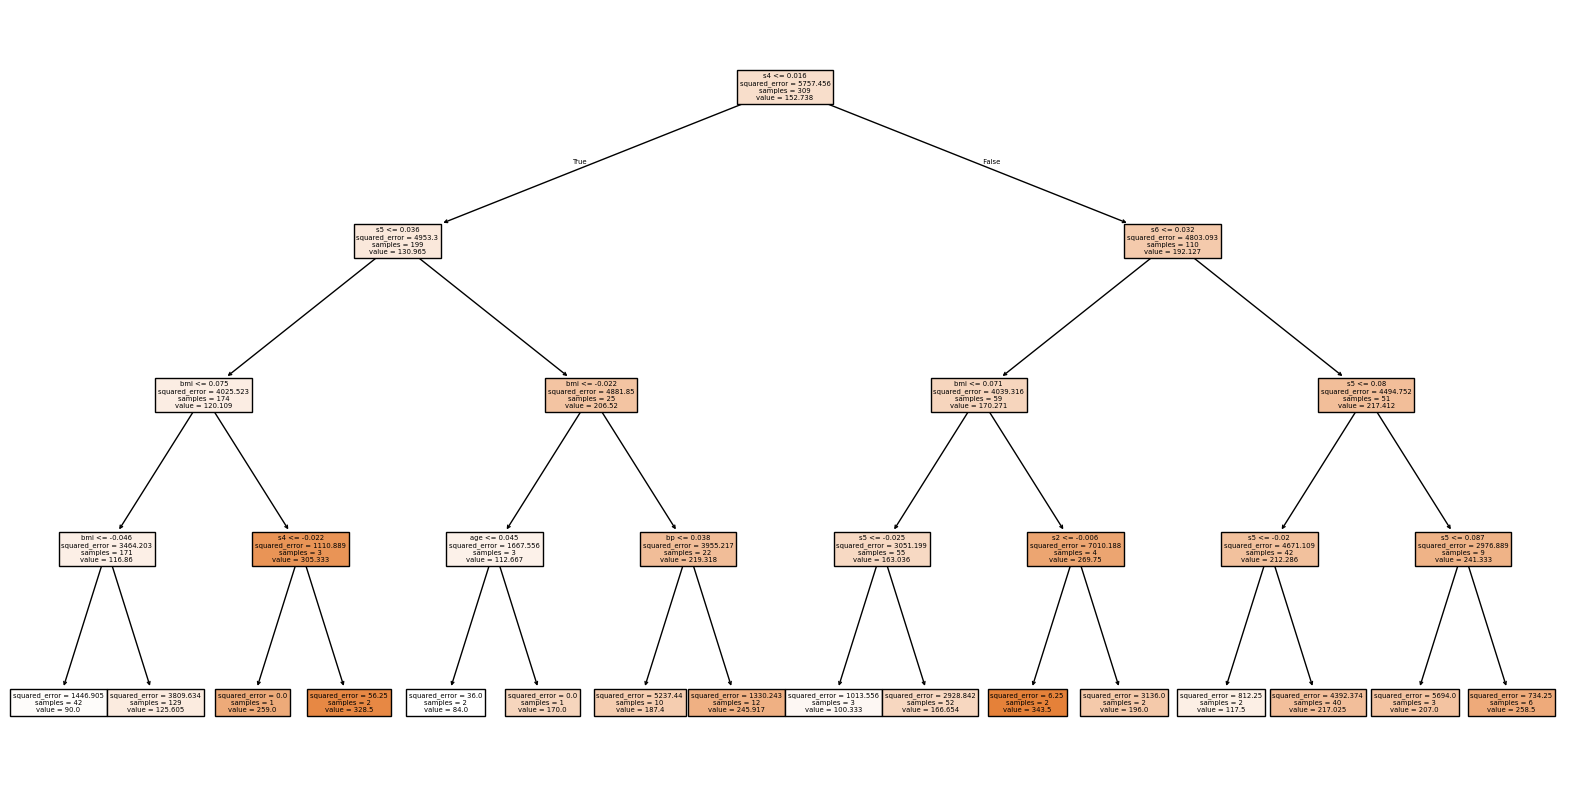

In [20]:
## Visualization of the Tree
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(selectedmodel, filled=True, feature_names=dataset.feature_names)
plt.show()